# Tratamento de inputação dos dados

## Bibliotecas

In [1]:
import sys
sys.path.append('/home/ismael/Documentos/GRANULARITY-PREDICTION/src/notebooks/funcoes')
import pandas as pd
import polars as pl
pl.enable_string_cache()
pd.set_option('future.no_silent_downcasting', True)
import glob
import os
import joblib
from funcoes_de_tratamento import *
import matplotlib.pyplot as plt
from time import perf_counter


/tmp/ipykernel_1184024/1087743236.py:5: DeprecationWarning: the string cache has been replaced by pl.Categories
  pl.enable_string_cache()


# Carregando e filtrando dados

1. Python is running from: /home/ismael/Documentos/GRANULARITY-PREDICTION/src/notebooks
2. Is the target path valid? True

--- All dataframes loaded successfully! ---
1. Python is running from: /home/ismael/Documentos/GRANULARITY-PREDICTION/src/notebooks
2. Is the target path valid? True

--- All dataframes loaded successfully! ---
1. Python is running from: /home/ismael/Documentos/GRANULARITY-PREDICTION/src/notebooks
2. Is the target path valid? True

--- All dataframes loaded successfully! ---


/home/ismael/Documentos/GRANULARITY-PREDICTION/src/notebooks/funcoes/funcoes_de_tratamento.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(lista_dia, ignore_index=True)


Instituições com poucos dados: 5
Instituições com variância zero: 0
Instituições com valores negativos: 0
Instituições com outliers: 176
Instituições restantes: 102


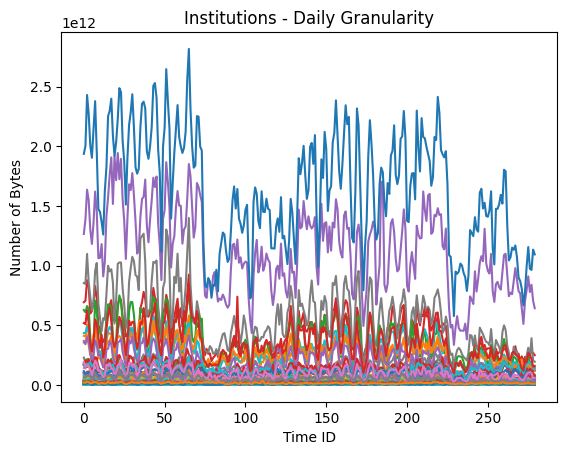

In [2]:

df_day = read_data('../../data/institutions/agg_1_day', features= None)
df_hour = read_data('../../data/institutions/agg_1_hour', features = None)
df_10min = read_data('../../data/institutions/agg_10_minutes', features = None)
#analise dos dados diários
inst = []
p_d = 0
val_null = 0
var_z = 0
val_neg = 0
out = 0
for i in df_day["id_institution"].unique():
    instituicao = df_day[df_day["id_institution"]==i]
    serve = True
    Q1 = instituicao["n_bytes"].quantile(0.20)
    Q3 = instituicao["n_bytes"].quantile(0.80)
    IQR = Q3 - Q1
    L_inferior = Q1 - 1.5*IQR
    L_superior = Q3 + 1.5*IQR

    #verifica se ha instituições com poucos dados e elimina elas se for o caso
    if instituicao.shape[0] < 260:
        #print(f"{i} tem poucos dados")
        #df_day = df_day[df_day["id_institution"]!=i]
        serve = False
        p_d += 1

        '''
    #verifica se ha instituições com valores nulos e elimina elas se for o caso
    elif instituicao[instituicao["n_bytes"].isnull()].shape[0]>0:
        #print(f"{i} tem valores nulos")
        #df_day = df_day[df_day["id_institution"]!=i]
        serve = False
        val_null += 1
        '''
        
    #verifica se ha instituições com variância zero e elimina elas se for o caso
    elif instituicao["n_bytes"].var() == 0:
        #print(f"{i} tem variância zero")
        #df_day = df_day[df_day["id_institution"]!=i]
        serve = False
        var_z += 1

    #verifica se ha instituições com valores negativos e elimina elas se for o caso
    elif instituicao[instituicao["n_bytes"]<0].shape[0]>0:
        #print(f"{i} tem valores negativos")
        #df_day = df_day[df_day["id_institution"]!=i]
        serve = False
        val_neg += 1

    #verifica se ha instituições com outliers (valores muito altos) e elimina elas se for o caso
    elif instituicao[(instituicao["n_bytes"] > L_superior) | (instituicao["n_bytes"] < L_inferior)].shape[0]>0:
        serve = False
        out += 1


    if serve:
        inst.append(i)

print(f"Instituições com poucos dados: {p_d}")
print(f"Instituições com variância zero: {var_z}")
print(f"Instituições com valores negativos: {val_neg}")
print(f"Instituições com outliers: {out}")
print(f"Instituições restantes: {len(inst)}")
for i in inst:
    instituicao = df_day[df_day["id_institution"]==i]
    
    plt.plot(instituicao["id_time"], instituicao["n_bytes"], label=i)
plt.title(f"Institutions - Daily Granularity")
plt.xlabel("Time ID")
plt.ylabel("Number of Bytes")
plt.show()

df_day = df_day[df_day["id_institution"].isin(inst)]
df_hour = df_hour[df_hour["id_institution"].isin(inst)]
df_10min = df_10min[df_10min["id_institution"].isin(inst)]


inst = [int(c) for c in inst]
joblib.dump(inst, "inst.joblib")

  
print()

## Testando multicolineariedade 

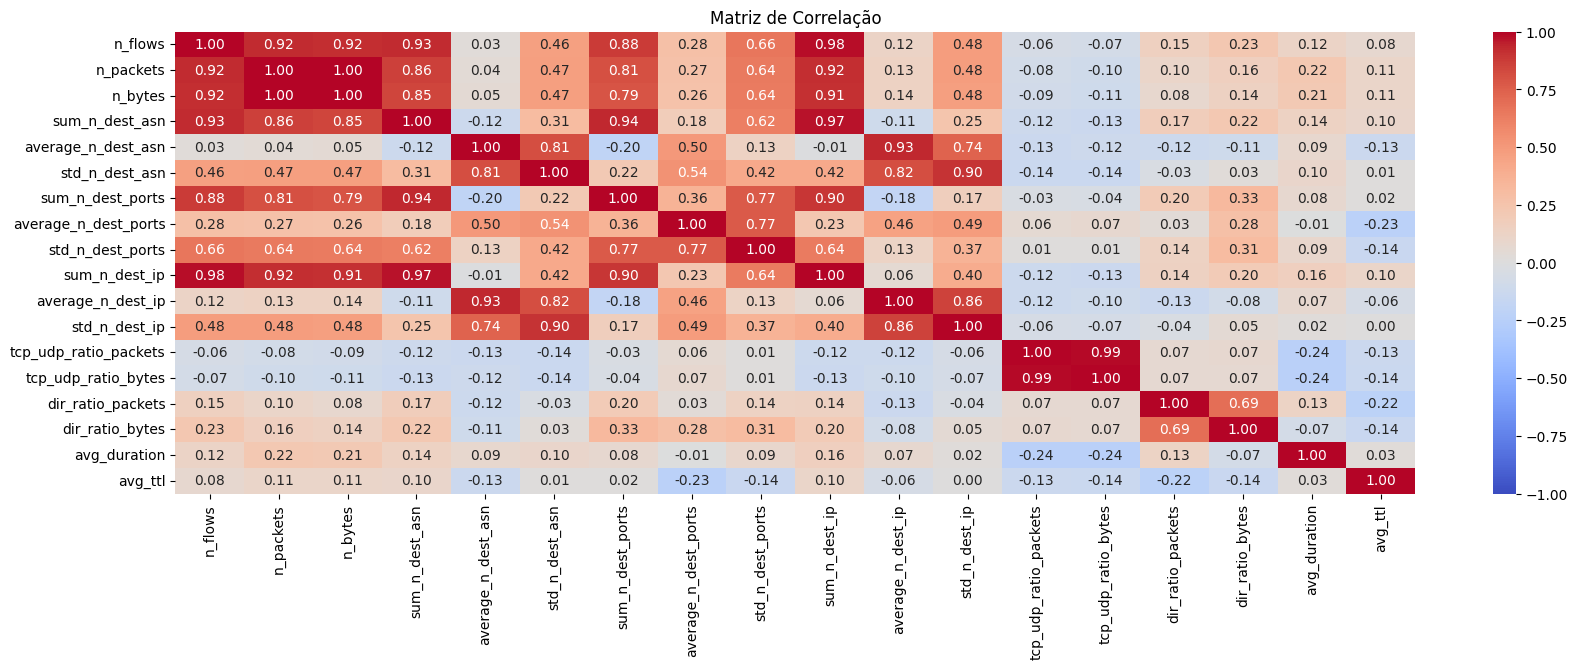

In [3]:
import seaborn as sns
corr = df_day.drop(columns= ["id_time", "id_institution"],axis= 1).corr(method= "spearman")


plt.figure(figsize=(20, 6))

# 4. Plota o Mapa de Calor
sns.heatmap(corr, 
            annot=True,       # Exibe os números dentro de cada quadrado
            cmap='coolwarm',  # Paleta de cores (azul para negativo, vermelho para positivo)
            fmt=".2f",        # Formata os números para 2 casas decimais
            vmin=-1,          # Fixa o limite mínimo da escala de cores em -1
            vmax=1)           # Fixa o limite máximo da escala de cores em 1

# 5. Adiciona título e exibe
plt.title('Matriz de Correlação')
plt.show()



In [ ]:
features_redundantes = ["n_packets", "tcp_udp_ratio_bytes"]
for col in df_day.columns:
    if "sum" in col:
        features_redundantes.append(str(col)) 
df_day = df_day.drop(columns=features_redundantes, axis= 1)
df_hour = df_hour.drop(columns=features_redundantes, axis= 1)
df_10min = df_10min.drop(columns=features_redundantes, axis= 1)

In [7]:
df_hour

,id_time,n_flows,n_bytes,sum_n_dest_asn,average_n_dest_asn,std_n_dest_asn,sum_n_dest_ports,average_n_dest_ports,std_n_dest_ports,sum_n_dest_ip,average_n_dest_ip,std_n_dest_ip,tcp_udp_ratio_packets,dir_ratio_packets,dir_ratio_bytes,avg_duration,avg_ttl,id_institution
33565,0,9622,2979420467,669,7.87,10.67,466,5.48,2.91,2633,30.98,92.06,0.90,0.46,0.41,14.80,155.83,137
33566,1,17989,1054940050,727,9.57,13.52,469,6.17,2.93,3765,49.54,147.28,0.88,0.50,0.46,16.35,152.60,137
33567,2,43869,16993391621,1178,14.02,26.08,526,6.26,4.07,7678,91.40,283.23,0.87,0.48,0.46,15.74,155.71,137
33568,3,45302,4096598792,1146,13.98,26.22,529,6.45,3.74,8039,98.04,309.85,0.92,0.52,0.48,18.40,145.91,137
33569,4,34978,2537640613,1023,12.63,25.61,439,5.42,3.68,7040,86.91,280.92,0.91,0.48,0.45,19.91,144.52,137
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1880177,6713,3385,896987700,683,8.99,13.95,1436,18.89,31.57,1905,25.07,55.91,0.77,0.48,0.49,13.40,121.40,83
1880178,6714,3826,706640309,740,8.92,14.46,1721,20.73,41.21,2019,24.33,58.58,0.79,0.44,0.44,16.44,130.92,83
1880179,6715,4171,12752171,758,9.72,14.48,2080,26.67,50.45,2051,26.29,57.28,0.88,0.47,0.47,19.06,123.94,83
1880180,6716,4301,748205549,754,9.31,15.51,2189,27.02,42.81,1920,23.70,54.95,0.84,0.44,0.48,15.05,129.12,83


/tmp/ipykernel_1180793/90882848.py:44: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acfs_por_categoria = df_day.groupby(coluna_categoria).apply(calcular_acf_grupo)
/tmp/ipykernel_1180793/90882848.py:45: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pacfs_por_categoria = df_day.groupby(coluna_categoria).apply(calcular_pacf_grupo)


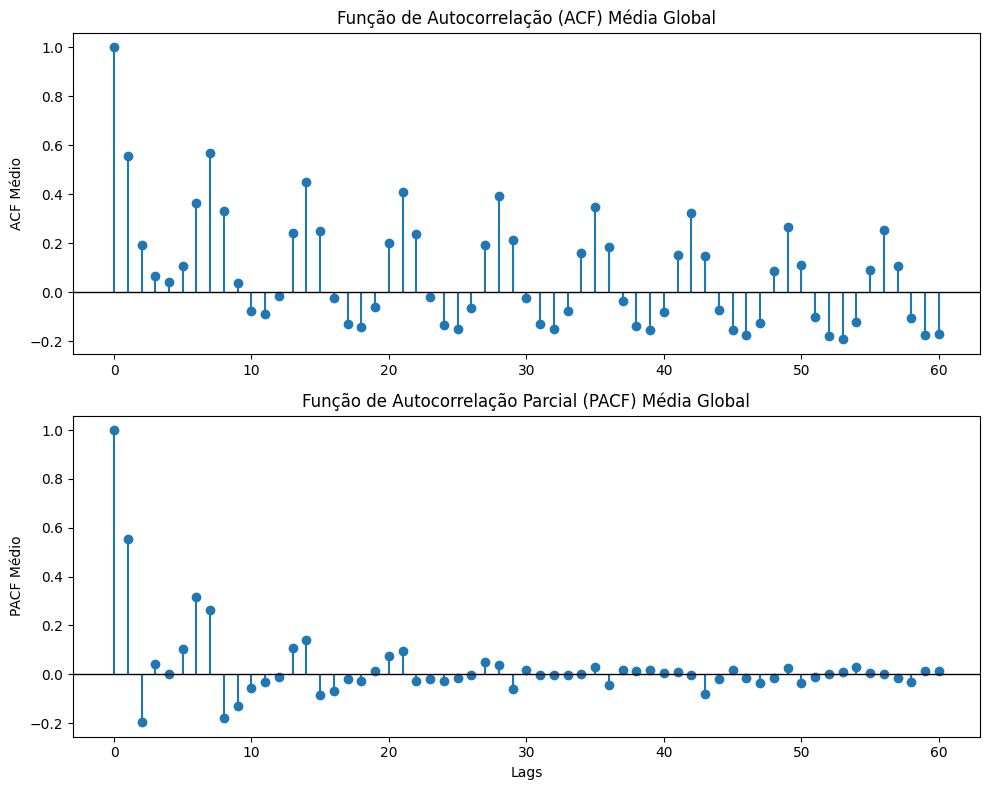

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf, pacf

# Variáveis de controle
coluna_categoria = 'id_institution' 
coluna_valor = 'n_bytes'         
lags_desejados = 60

# 1. Função para calcular o ACF isolado
def calcular_acf_grupo(grupo):
    nlags_reais = min(lags_desejados, len(grupo) - 2)
    
    if nlags_reais <= 0:
        return np.full(lags_desejados + 1, np.nan) 
        
    resultado_acf = acf(grupo[coluna_valor], nlags=nlags_reais, fft=True)
    
    if len(resultado_acf) < lags_desejados + 1:
        padding = np.full((lags_desejados + 1) - len(resultado_acf), np.nan)
        resultado_acf = np.concatenate((resultado_acf, padding))
        
    return resultado_acf

# 2. Função para calcular o PACF isolado
def calcular_pacf_grupo(grupo):
    # O PACF exige restrição mais forte de lags (menor que a metade do tamanho da série)
    nlags_reais = min(lags_desejados, (len(grupo) // 2) - 1)
    
    if nlags_reais <= 0:
        return np.full(lags_desejados + 1, np.nan) 
        
    # Usando method='ywm' (o método padrão e eficiente do PACF, já que não possui fft=True)
    resultado_pacf = pacf(grupo[coluna_valor], nlags=nlags_reais, method='ywm')
    
    if len(resultado_pacf) < lags_desejados + 1:
        padding = np.full((lags_desejados + 1) - len(resultado_pacf), np.nan)
        resultado_pacf = np.concatenate((resultado_pacf, padding))
        
    return resultado_pacf

# 3. Aplica a função por categoria
acfs_por_categoria = df_day.groupby(coluna_categoria).apply(calcular_acf_grupo)
pacfs_por_categoria = df_day.groupby(coluna_categoria).apply(calcular_pacf_grupo)

# 4. Converte o resultado em um DataFrame 
df_acfs = pd.DataFrame(acfs_por_categoria.tolist(), index=acfs_por_categoria.index)
df_pacfs = pd.DataFrame(pacfs_por_categoria.tolist(), index=pacfs_por_categoria.index)

# 5. Calcula a média para cada lag (ignorando NaNs)
acf_medio = df_acfs.mean(axis=0)
pacf_medio = df_pacfs.mean(axis=0)

# 6. Plotando os dois resultados em gráficos empilhados
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Plot do ACF
axes[0].stem(range(len(acf_medio)), acf_medio, basefmt=" ")
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Função de Autocorrelação (ACF) Média Global')
axes[0].set_ylabel('ACF Médio')

# Plot do PACF
axes[1].stem(range(len(pacf_medio)), pacf_medio, basefmt=" ")
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Função de Autocorrelação Parcial (PACF) Média Global')
axes[1].set_xlabel('Lags')
axes[1].set_ylabel('PACF Médio')

plt.tight_layout()
plt.show()

## Tranformando ids temporais faltantes em espaços em branco

### Identificando ids faltantes

In [8]:
time_day = pd.read_csv('../../data/times/times_1_day.csv')
time_hour = pd.read_csv('../../data/times/times_1_hour.csv')
time_minute = pd.read_csv('../../data/times/times_10_minutes.csv')

df_day["id_time"] = df_day["id_time"].astype(int)
df_hour["id_time"] = df_hour["id_time"].astype(int)
df_10min["id_time"] = df_10min["id_time"].astype(int)

df_day = df_day.merge(time_day, on="id_time", how="left")
df_day["time"] = pd.to_datetime(df_day["time"])
df_day["time"] = pd.to_datetime(pd.DataFrame(
        {
            "year": df_day["time"].dt.year.astype("int"),
            "month": df_day["time"].dt.month.astype("int"),
            "day": df_day["time"].dt.day.astype("int"),
            "hour": df_day["time"].dt.hour.astype("int"),
            "minute": (round(df_day["time"].dt.minute.astype("int") /10))*10,
            "second": 0

        }
    )
)
df_day["id_institution"] = df_day["id_institution"].astype("int")
df_day = df_day.sort_values(by = ["time", "id_institution"])
df_day.drop(columns=["id_time"], inplace=True)

df_hour = df_hour.merge(time_hour, on="id_time", how="left")
df_hour["time"] = pd.to_datetime(df_hour["time"])
df_hour["time"] = pd.to_datetime(pd.DataFrame(
        {
            "year": df_hour["time"].dt.year.astype("int"),
            "month": df_hour["time"].dt.month.astype("int"),
            "day": df_hour["time"].dt.day.astype("int"),
            "hour": df_hour["time"].dt.hour.astype("int"),
            "minute": (round(df_hour["time"].dt.minute.astype("int") /10))*10,
            "second": 0

        }
    )
)
df_hour["id_institution"] = df_hour["id_institution"].astype("int")
df_hour = df_hour.sort_values(by = ["time", "id_institution"])
df_hour.drop(columns=["id_time"], inplace=True)

df_10min = df_10min.merge(time_minute, on="id_time", how="left")
df_10min["time"] = pd.to_datetime(df_10min["time"], utc = True)
df_10min["time"] = pd.to_datetime(pd.DataFrame(
        {
            "year": df_10min["time"].dt.year.astype("int"),
            "month": df_10min["time"].dt.month.astype("int"),
            "day": df_10min["time"].dt.day.astype("int"),
            "hour": df_10min["time"].dt.hour.astype("int"),
            "minute": (round(df_10min["time"].dt.minute.astype("int") /10))*10,
            "second": 0

        }
    )
)

df_10min["id_institution"] = df_10min["id_institution"].astype("int")
df_10min = df_10min.sort_values(by = ["time", "id_institution"])
df_10min.drop(columns=["id_time"], inplace=True)


In [ ]:
df_day["id_institution"].value_counts()

id_institution
0      280
3      280
4      280
5      280
8      280
      ... 
244    280
249    280
254    280
265    280
284    280
Name: count, Length: 102, dtype: int64

In [ ]:
df_hour["id_institution"].value_counts()

id_institution
0      6717
3      6717
4      6717
5      6717
9      6717
       ... 
239    6705
8      6703
72     6699
265    6654
243    6534
Name: count, Length: 102, dtype: int64

In [ ]:
df_10min["id_institution"].value_counts()

id_institution
0      40298
3      40298
10     40298
9      40298
23     40298
       ...  
203    21934
265    10205
72      8281
222     6603
151     3402
Name: count, Length: 102, dtype: int64

### Criando mascara temporal e ligando com os dados

In [9]:
series_day = pd.Series( pd.date_range(start = df_day["time"].min(), end = df_day["time"].max(), freq = "D"), name = "time")
display(series_day)

series_hour = pd.Series(pd.date_range(start=df_hour["time"].min(), end=df_hour["time"].max(), freq='h'), name="time")
display(series_hour)

series_10min = pd.Series(pd.date_range(start=df_10min["time"].min(), end=df_10min["time"].max(), freq='10min'), name="time")
display(series_10min)


0     2023-10-09
1     2023-10-10
2     2023-10-11
3     2023-10-12
4     2023-10-13
         ...    
275   2024-07-10
276   2024-07-11
277   2024-07-12
278   2024-07-13
279   2024-07-14
Name: time, Length: 280, dtype: datetime64[ns]

0      2023-10-09 00:00:00
1      2023-10-09 01:00:00
2      2023-10-09 02:00:00
3      2023-10-09 03:00:00
4      2023-10-09 04:00:00
               ...        
6713   2024-07-14 17:00:00
6714   2024-07-14 18:00:00
6715   2024-07-14 19:00:00
6716   2024-07-14 20:00:00
6717   2024-07-14 21:00:00
Name: time, Length: 6718, dtype: datetime64[ns]

0       2023-10-09 00:00:00
1       2023-10-09 00:10:00
2       2023-10-09 00:20:00
3       2023-10-09 00:30:00
4       2023-10-09 00:40:00
                ...        
40303   2024-07-14 21:10:00
40304   2024-07-14 21:20:00
40305   2024-07-14 21:30:00
40306   2024-07-14 21:40:00
40307   2024-07-14 21:50:00
Name: time, Length: 40308, dtype: datetime64[ns]

In [10]:
dfs = []
for id in inst:
    df_d = df_day[df_day["id_institution"] ==  id].copy()
    df_d = df_d.merge(series_day, on = "time", how = "right")
    df_d["id_institution"] = df_d["id_institution"].fillna(id).astype("int")
    df_d["n_bytes"] = df_d["n_bytes"].bfill().ffill()
    dfs.append(df_d)

df_day = pd.concat(dfs)


dfs = []
for id in inst:
    df_h = df_hour[df_hour["id_institution"] ==  id].copy()
    df_h = df_h.merge(series_hour, on = "time", how = "right")
    
    df_h["id_institution"] =df_h["id_institution"].fillna(id).astype("int")
    dfs.append(df_h)

df_hour = pd.concat(dfs)

dfs = []
for id in inst:
    df_m = df_10min[df_10min["id_institution"] ==  id].copy()
    df_m = df_m.merge(series_10min, on = "time", how = "right")
    df_m["id_institution"] = df_m["id_institution"].fillna(id).astype("int")
    dfs.append(df_m)

df_10min = pd.concat(dfs)

In [11]:
display(df_day)
display(df_hour)
display(df_10min)

,n_flows,n_bytes,average_n_dest_asn,std_n_dest_asn,average_n_dest_ports,std_n_dest_ports,average_n_dest_ip,std_n_dest_ip,tcp_udp_ratio_packets,dir_ratio_packets,dir_ratio_bytes,avg_duration,avg_ttl,id_institution,time
0,480822,104254214117,10.73,20.72,5.63,5.17,62.55,207.33,0.89,0.48,0.45,16.23,152.11,137,2023-10-09
1,402227,77598243579,10.02,18.62,4.93,3.67,56.34,183.28,0.86,0.48,0.44,16.06,151.08,137,2023-10-10
2,456772,107828916252,10.56,18.85,5.49,4.16,59.19,195.50,0.87,0.47,0.43,14.29,151.65,137,2023-10-11
3,486108,75404450175,11.41,21.15,5.49,3.89,62.86,205.24,0.87,0.47,0.43,14.09,153.08,137,2023-10-12
4,508390,73054357548,12.61,22.68,6.23,4.33,63.37,204.09,0.88,0.44,0.40,12.87,164.75,137,2023-10-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
275,149286,20056212285,9.66,18.52,15.45,70.63,37.08,115.26,0.84,0.50,0.49,16.27,123.49,83,2024-07-10
276,134146,9558339042,9.31,17.37,15.77,19.44,38.39,110.27,0.85,0.48,0.49,15.79,124.78,83,2024-07-11
277,126761,11933568726,9.26,16.41,12.90,16.72,35.45,105.70,0.84,0.47,0.46,16.28,119.73,83,2024-07-12
278,50625,8496556858,6.79,7.09,11.40,14.96,16.45,28.73,0.81,0.47,0.47,16.23,125.32,83,2024-07-13


,n_flows,n_bytes,sum_n_dest_asn,average_n_dest_asn,std_n_dest_asn,sum_n_dest_ports,average_n_dest_ports,std_n_dest_ports,sum_n_dest_ip,average_n_dest_ip,std_n_dest_ip,tcp_udp_ratio_packets,dir_ratio_packets,dir_ratio_bytes,avg_duration,avg_ttl,id_institution,time
0,9622.0,2.979420e+09,669.0,7.87,10.67,466.0,5.48,2.91,2633.0,30.98,92.06,0.90,0.46,0.41,14.80,155.83,137,2023-10-09 00:00:00
1,17989.0,1.054940e+09,727.0,9.57,13.52,469.0,6.17,2.93,3765.0,49.54,147.28,0.88,0.50,0.46,16.35,152.60,137,2023-10-09 01:00:00
2,43869.0,1.699339e+10,1178.0,14.02,26.08,526.0,6.26,4.07,7678.0,91.40,283.23,0.87,0.48,0.46,15.74,155.71,137,2023-10-09 02:00:00
3,45302.0,4.096599e+09,1146.0,13.98,26.22,529.0,6.45,3.74,8039.0,98.04,309.85,0.92,0.52,0.48,18.40,145.91,137,2023-10-09 03:00:00
4,34978.0,2.537641e+09,1023.0,12.63,25.61,439.0,5.42,3.68,7040.0,86.91,280.92,0.91,0.48,0.45,19.91,144.52,137,2023-10-09 04:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6713,3385.0,8.969877e+08,683.0,8.99,13.95,1436.0,18.89,31.57,1905.0,25.07,55.91,0.77,0.48,0.49,13.40,121.40,83,2024-07-14 17:00:00
6714,3826.0,7.066403e+08,740.0,8.92,14.46,1721.0,20.73,41.21,2019.0,24.33,58.58,0.79,0.44,0.44,16.44,130.92,83,2024-07-14 18:00:00
6715,4171.0,1.275217e+07,758.0,9.72,14.48,2080.0,26.67,50.45,2051.0,26.29,57.28,0.88,0.47,0.47,19.06,123.94,83,2024-07-14 19:00:00
6716,4301.0,7.482055e+08,754.0,9.31,15.51,2189.0,27.02,42.81,1920.0,23.70,54.95,0.84,0.44,0.48,15.05,129.12,83,2024-07-14 20:00:00


,n_flows,n_bytes,sum_n_dest_asn,average_n_dest_asn,std_n_dest_asn,sum_n_dest_ports,average_n_dest_ports,std_n_dest_ports,sum_n_dest_ip,average_n_dest_ip,std_n_dest_ip,tcp_udp_ratio_packets,dir_ratio_packets,dir_ratio_bytes,avg_duration,avg_ttl,id_institution,time
0,1527,796727424,120,9.23,10.30,95,7.31,3.57,409,31.46,85.56,0.91,0.39,0.37,9.28,165.55,137,2023-10-09 00:00:00
1,1445,35517598,108,7.20,9.17,73,4.87,2.53,378,25.20,75.26,0.97,0.54,0.48,12.63,147.88,137,2023-10-09 00:10:00
2,1396,22809023,103,7.36,11.56,73,5.21,3.45,427,30.50,95.73,0.82,0.51,0.46,33.21,149.07,137,2023-10-09 00:20:00
3,1614,46543563,115,8.21,11.40,73,5.21,2.19,454,32.43,97.80,0.89,0.40,0.31,9.79,167.49,137,2023-10-09 00:30:00
4,1636,2019183184,93,7.15,9.77,63,4.85,2.91,416,32.00,95.29,0.91,0.49,0.39,11.71,146.58,137,2023-10-09 00:40:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40303,759,3511381,135,10.38,17.65,383,29.46,43.61,337,25.92,63.58,0.95,0.43,0.45,15.54,124.53,83,2024-07-14 21:10:00
40304,536,1774880,129,9.21,15.16,204,14.57,18.82,315,22.50,53.09,0.77,0.51,0.51,19.00,127.49,83,2024-07-14 21:20:00
40305,695,668945468,140,11.67,17.93,327,27.25,52.47,348,29.00,63.23,0.81,0.44,0.44,21.86,133.83,83,2024-07-14 21:30:00
40306,566,53912021,131,10.08,13.91,232,17.85,24.76,338,26.00,55.15,0.80,0.43,0.45,21.86,106.43,83,2024-07-14 21:40:00


In [12]:
df_day["time_d"] = df_day["time"].dt.date
df_hour["time_d"] = df_hour["time"].dt.date
df_hour["time_h"] = pd.to_datetime(pd.DataFrame(
        {
            "year": df_hour["time"].dt.year.astype("int"),
            "month": df_hour["time"].dt.month.astype("int"),
            "day": df_hour["time"].dt.day.astype("int"),
            "hour": df_hour["time"].dt.hour.astype("int"),
            "minute": 0,
            "second": 0

        }
    )
)

df_10min["time_h"] = pd.to_datetime(pd.DataFrame(
        {
            "year": df_10min["time"].dt.year.astype("int"),
            "month": df_10min["time"].dt.month.astype("int"),
            "day": df_10min["time"].dt.day.astype("int"),
            "hour": df_10min["time"].dt.hour.astype("int"),
            "minute": 0,
            "second": 0

        }
    )
)

In [24]:
display(df_day)
display(df_hour)
display(df_10min)

,n_flows,n_packets,n_bytes,sum_n_dest_asn,average_n_dest_asn,std_n_dest_asn,sum_n_dest_ports,average_n_dest_ports,std_n_dest_ports,sum_n_dest_ip,...,std_n_dest_ip,tcp_udp_ratio_packets,tcp_udp_ratio_bytes,dir_ratio_packets,dir_ratio_bytes,avg_duration,avg_ttl,id_institution,time,time_d
0,480822,94976198,104254214117,19172,10.73,20.72,10063,5.63,5.17,111709,...,207.33,0.89,0.88,0.48,0.45,16.23,152.11,137,2023-10-09,2023-10-09
1,402227,72886561,77598243579,17731,10.02,18.62,8730,4.93,3.67,99662,...,183.28,0.86,0.85,0.48,0.44,16.06,151.08,137,2023-10-10,2023-10-10
2,456772,99642559,107828916252,19492,10.56,18.85,10138,5.49,4.16,109212,...,195.50,0.87,0.86,0.47,0.43,14.29,151.65,137,2023-10-11,2023-10-11
3,486108,74464255,75404450175,20888,11.41,21.15,10046,5.49,3.89,115094,...,205.24,0.87,0.87,0.47,0.43,14.09,153.08,137,2023-10-12,2023-10-12
4,508390,70645820,73054357548,23170,12.61,22.68,11442,6.23,4.33,116403,...,204.09,0.88,0.88,0.44,0.40,12.87,164.75,137,2023-10-13,2023-10-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
275,149286,24587221,20056212285,17322,9.66,18.52,27726,15.45,70.63,66529,...,115.26,0.84,0.83,0.50,0.49,16.27,123.49,83,2024-07-10,2024-07-10
276,134146,14412045,9558339042,16621,9.31,17.37,28166,15.77,19.44,68563,...,110.27,0.85,0.84,0.48,0.49,15.79,124.78,83,2024-07-11,2024-07-11
277,126761,17638335,11933568726,17280,9.26,16.41,24089,12.90,16.72,66180,...,105.70,0.84,0.83,0.47,0.46,16.28,119.73,83,2024-07-12,2024-07-12
278,50625,10171644,8496556858,12795,6.79,7.09,21482,11.40,14.96,30996,...,28.73,0.81,0.80,0.47,0.47,16.23,125.32,83,2024-07-13,2024-07-13


,n_flows,n_packets,n_bytes,sum_n_dest_asn,average_n_dest_asn,std_n_dest_asn,sum_n_dest_ports,average_n_dest_ports,std_n_dest_ports,sum_n_dest_ip,...,tcp_udp_ratio_packets,tcp_udp_ratio_bytes,dir_ratio_packets,dir_ratio_bytes,avg_duration,avg_ttl,id_institution,time,time_d,time_h
0,9622.0,2347490.0,2.979420e+09,669.0,7.87,10.67,466.0,5.48,2.91,2633.0,...,0.90,0.90,0.46,0.41,14.80,155.83,137,2023-10-09 00:00:00,2023-10-09,2023-10-09 00:00:00
1,17989.0,1250092.0,1.054940e+09,727.0,9.57,13.52,469.0,6.17,2.93,3765.0,...,0.88,0.88,0.50,0.46,16.35,152.60,137,2023-10-09 01:00:00,2023-10-09,2023-10-09 01:00:00
2,43869.0,13128955.0,1.699339e+10,1178.0,14.02,26.08,526.0,6.26,4.07,7678.0,...,0.87,0.87,0.48,0.46,15.74,155.71,137,2023-10-09 02:00:00,2023-10-09,2023-10-09 02:00:00
3,45302.0,4351044.0,4.096599e+09,1146.0,13.98,26.22,529.0,6.45,3.74,8039.0,...,0.92,0.91,0.52,0.48,18.40,145.91,137,2023-10-09 03:00:00,2023-10-09,2023-10-09 03:00:00
4,34978.0,2925491.0,2.537641e+09,1023.0,12.63,25.61,439.0,5.42,3.68,7040.0,...,0.91,0.90,0.48,0.45,19.91,144.52,137,2023-10-09 04:00:00,2023-10-09,2023-10-09 04:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6713,3385.0,1552687.0,8.969877e+08,683.0,8.99,13.95,1436.0,18.89,31.57,1905.0,...,0.77,0.77,0.48,0.49,13.40,121.40,83,2024-07-14 17:00:00,2024-07-14,2024-07-14 17:00:00
6714,3826.0,610417.0,7.066403e+08,740.0,8.92,14.46,1721.0,20.73,41.21,2019.0,...,0.79,0.79,0.44,0.44,16.44,130.92,83,2024-07-14 18:00:00,2024-07-14,2024-07-14 18:00:00
6715,4171.0,56733.0,1.275217e+07,758.0,9.72,14.48,2080.0,26.67,50.45,2051.0,...,0.88,0.88,0.47,0.47,19.06,123.94,83,2024-07-14 19:00:00,2024-07-14,2024-07-14 19:00:00
6716,4301.0,889520.0,7.482055e+08,754.0,9.31,15.51,2189.0,27.02,42.81,1920.0,...,0.84,0.82,0.44,0.48,15.05,129.12,83,2024-07-14 20:00:00,2024-07-14,2024-07-14 20:00:00


,n_flows,n_packets,n_bytes,sum_n_dest_asn,average_n_dest_asn,std_n_dest_asn,sum_n_dest_ports,average_n_dest_ports,std_n_dest_ports,sum_n_dest_ip,...,std_n_dest_ip,tcp_udp_ratio_packets,tcp_udp_ratio_bytes,dir_ratio_packets,dir_ratio_bytes,avg_duration,avg_ttl,id_institution,time,time_h
0,1527,721158,796727424,120,9.23,10.30,95,7.31,3.57,409,...,85.56,0.91,0.89,0.39,0.37,9.28,165.55,137,2023-10-09 00:00:00,2023-10-09 00:00:00
1,1445,43833,35517598,108,7.20,9.17,73,4.87,2.53,378,...,75.26,0.97,0.96,0.54,0.48,12.63,147.88,137,2023-10-09 00:10:00,2023-10-09 00:00:00
2,1396,46172,22809023,103,7.36,11.56,73,5.21,3.45,427,...,95.73,0.82,0.83,0.51,0.46,33.21,149.07,137,2023-10-09 00:20:00,2023-10-09 00:00:00
3,1614,61833,46543563,115,8.21,11.40,73,5.21,2.19,454,...,97.80,0.89,0.90,0.40,0.31,9.79,167.49,137,2023-10-09 00:30:00,2023-10-09 00:00:00
4,1636,1404398,2019183184,93,7.15,9.77,63,4.85,2.91,416,...,95.29,0.91,0.90,0.49,0.39,11.71,146.58,137,2023-10-09 00:40:00,2023-10-09 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40303,759,7813,3511381,135,10.38,17.65,383,29.46,43.61,337,...,63.58,0.95,0.97,0.43,0.45,15.54,124.53,83,2024-07-14 21:10:00,2024-07-14 21:00:00
40304,536,8160,1774880,129,9.21,15.16,204,14.57,18.82,315,...,53.09,0.77,0.74,0.51,0.51,19.00,127.49,83,2024-07-14 21:20:00,2024-07-14 21:00:00
40305,695,522064,668945468,140,11.67,17.93,327,27.25,52.47,348,...,63.23,0.81,0.80,0.44,0.44,21.86,133.83,83,2024-07-14 21:30:00,2024-07-14 21:00:00
40306,566,301782,53912021,131,10.08,13.91,232,17.85,24.76,338,...,55.15,0.80,0.80,0.43,0.45,21.86,106.43,83,2024-07-14 21:40:00,2024-07-14 21:00:00


In [13]:
df_hour_ = df_hour.copy()
del df_hour
df_10min_ = df_10min.copy()
del df_10min

## XGboost para escolha de variáveis

Lags originais: 12
Lags retidos após corte: 5
Lista de variáveis mantidas: ['n_flows', 'average_n_dest_asn', 'average_n_dest_ip', 'std_n_dest_asn', 'average_n_dest_ports']


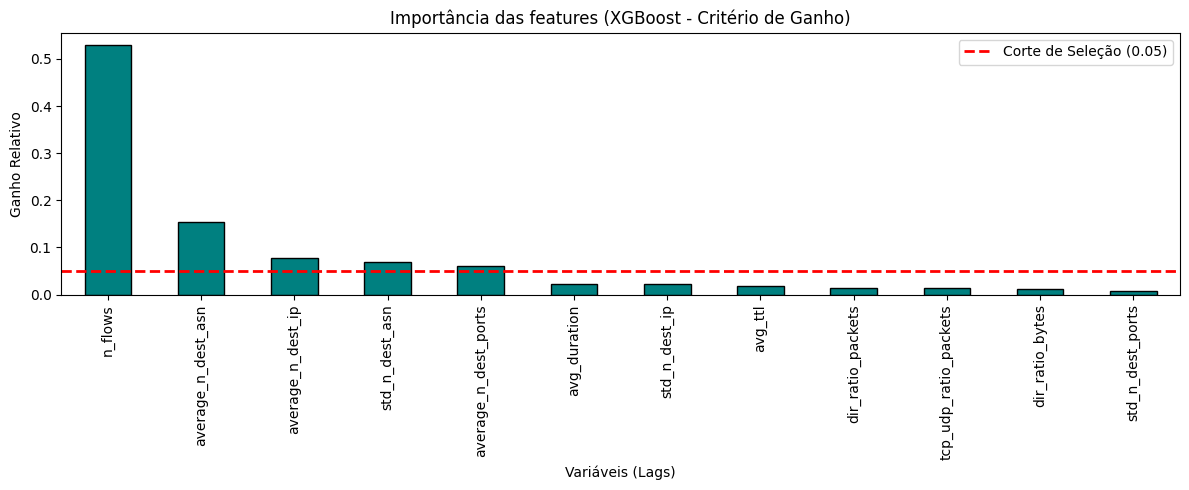

In [17]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# DADOS DE EXEMPLO (Substitua pelos seus dados reais)
# ---------------------------------------------------------
# X = sua matriz de janela deslizante contendo apenas os lags
# y = a variável contínua ou categórica que você deseja prever
np.random.seed(42)
X = df_day.drop(columns=["id_institution", "time", "n_bytes", "time_d"], axis = 1)
# Simulando que apenas o lag_1 e lag_5 têm relação real com o alvo:
y = df_day["n_bytes"]

# ---------------------------------------------------------
# 1. CONFIGURAÇÃO E TREINAMENTO DO XGBOOST
# ---------------------------------------------------------
# Utilize parâmetros conservadores (max_depth baixo) para evitar 
# que o modelo decore o ruído (overfitting) e gere falsas importâncias.
modelo_xgb = xgb.XGBRegressor(
    n_estimators=100,    # Número de árvores
    max_depth=4,         # Profundidade máxima (4 a 6 é o ideal para seleção)
    learning_rate=0.1,   # Taxa de aprendizado
    random_state=42
)

# Treina o modelo na matriz completa
modelo_xgb.fit(X, y)

# ---------------------------------------------------------
# 2. EXTRAÇÃO DAS IMPORTÂNCIAS
# ---------------------------------------------------------
# Extrai o array de importâncias e converte em uma Série do Pandas
importancias = pd.Series(modelo_xgb.feature_importances_, index=X.columns)
importancias_ordenadas = importancias.sort_values(ascending=False)

# ---------------------------------------------------------
# 3. APLICAÇÃO DO CORTE (THRESHOLD)
# ---------------------------------------------------------
# Defina o critério rigoroso para manter uma coluna. 
# Aqui, mantemos apenas lags cuja importância seja maior que 1% (0.01).
limiar_corte = 0.05
lags_selecionados = importancias_ordenadas[importancias_ordenadas > limiar_corte].index

print(f"Lags originais: {X.shape[1]}")
print(f"Lags retidos após corte: {len(lags_selecionados)}")
print(f"Lista de variáveis mantidas: {list(lags_selecionados)}")

# 4. GERAÇÃO DA MATRIZ REDUZIDA
# Esta é a matriz final que você usará no seu pipeline real
X_reduzido = X[lags_selecionados]

# ---------------------------------------------------------
# 5. VISUALIZAÇÃO DOS RESULTADOS
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))
# Plota apenas os top 20 para manter o gráfico legível
importancias_ordenadas.head(20).plot(kind='bar', color='teal', edgecolor='black')
plt.axhline(limiar_corte, color='red', linestyle='--', linewidth=2, label=f'Corte de Seleção ({limiar_corte})')

plt.title('Importância das features (XGBoost - Critério de Ganho)')
plt.ylabel('Ganho Relativo')
plt.xlabel('Variáveis (Lags)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
features = 

## Testando técnicas de imputação

### resetando nulos

In [ ]:
df_hour = df_hour_.copy()
df_10min = df_10min_.copy()

NameError: name 'df_hour_' is not defined

In [ ]:
elapsed_time = {
    "granufill": {"hour": None, "10min": None},
    "mavg_fill": {"hour": None, "10min": None},
    "mmedian_fill": {"hour": None, "10min": None},
    "knn_fill": {"hour": None, "10min": None},
    "svd_fill": {"hour": None, "10min": None},
}

### Granufill

In [ ]:


start = perf_counter()
df_hour = granufill(df_day, df_hour, ["id_institution", "time"], "n_bytes", 24)
end = perf_counter()
elapsed_time["granufill"]["hour"] = end - start

start = perf_counter()
df_10min = granufill(df_hour, df_10min, ["id_institution", "time"], "n_bytes", 24*6)
end = perf_counter()
elapsed_time["granufill"]["10min"] = end - start

### Média Móvel

In [ ]:

start = perf_counter()
for id in inst:
    filtro_hour = df_hour["id_institution"] == id
    df_hour.loc[filtro_hour, "n_bytes" ] = moving_average_fill(df_hour[filtro_hour, "n_bytes" ], window_size = 24)
end = perf_counter()
elapsed_time["mavg_fill"]["hour"] = end - start

start = perf_counter()
for id in inst:
    filtro_10min = df_10min["id_institution"] == id
    df_10min.loc[filtro_10min, "n_bytes" ] = moving_average_fill(df_10min.loc[filtro_10min, "n_bytes" ], window_size= 24*6)
end = perf_counter()
elapsed_time["mavg_fill"]["10min"] = end - start

### Mediana móvel

In [ ]:
start = perf_counter()
for id in inst:
    filtro_hour = df_hour["id_institution"] == id
    df_hour.loc[filtro_hour, "n_bytes" ] = moving_median_fill(df_hour[filtro_hour, "n_bytes" ], window_size = 24)
end = perf_counter()
elapsed_time["mmedian_fill"]["10min"] = end - start

start = perf_counter()
for id in inst:
    filtro_10min = df_10min["id_institution"] == id
    df_10min.loc[filtro_10min, "n_bytes" ] = moving_median_fill(df_10min.loc[filtro_10min, "n_bytes" ], window_size= 24*6)
end = perf_counter()
elapsed_time["mmedian_fill"]["10min"] = end - start

### KNN

In [ ]:
start = perf_counter()
for id in inst:
    filtro_hour = df_hour["id_institution"] == id
    df_hour.loc[filtro_hour, "n_bytes" ] = knn_fill_missing(df_hour[filtro_hour, "n_bytes" ], k = 24)
end = perf_counter()
elapsed_time["knn_fill"]["10min"] = end - start

start = perf_counter()
for id in inst:
    filtro_10min = df_10min["id_institution"] == id
    df_10min.loc[filtro_10min, "n_bytes" ] = knn_fill_missing(df_10min.loc[filtro_10min, "n_bytes" ], k = 24*6)
end = perf_counter()
elapsed_time["knn_fill"]["10min"] = end - start

### SVD

In [ ]:
start = perf_counter()
for id in inst:
    filtro_hour = df_hour["id_institution"] == id
    df_hour.loc[filtro_hour, "n_bytes" ] = svd_fill_missing(df_hour[filtro_hour, "n_bytes" ], window_size = 24)
end = perf_counter()
elapsed_time["knn_fill"]["10min"] = end - start

start = perf_counter()
for id in inst:
    filtro_10min = df_10min["id_institution"] == id
    df_10min.loc[filtro_10min, "n_bytes" ] = svd_fill_missing(df_10min.loc[filtro_10min, "n_bytes" ], window_size= 24*6)
end = perf_counter()
elapsed_time["knn_fill"]["10min"] = end - start

## Resultados:

In [ ]:
print(f"""Tempo de execução de cada método:

GRANUFILL:
    Horário: {elapsed_time['granufill']['hour']}
    10 min:  {elapsed_time['granufill']['10min']}

MÉDIA MÓVEL (mavg_fill):
    Horário: {elapsed_time['mavg_fill']['hour']}
    10 min:  {elapsed_time['mavg_fill']['10min']}

MEDIANA MÓVEL (mmedian_fill):
    Horário: {elapsed_time['mmedian_fill']['hour']}
    10 min:  {elapsed_time['mmedian_fill']['10min']}

KNN (knn_fill):
    Horário: {elapsed_time['knn_fill']['hour']}
    10 min:  {elapsed_time['knn_fill']['10min']}

SVD (svd_fill):
    Horário: {elapsed_time['svd_fill']['hour']}
    10 min:  {elapsed_time['svd_fill']['10min']}
""")


In [ ]:
atributos = ["time", "id_institution", "n_bytes"]
df_day = df_day[atributos].drop_duplicates()
df_hour = df_hour[atributos].drop_duplicates()
df_10min = df_10min[atributos].drop_duplicates()

In [ ]:
display(df_day)
display(df_hour)
display(df_10min)

,time,id_institution,n_bytes
0,2023-10-09,137,104254214117
1,2023-10-10,137,77598243579
2,2023-10-11,137,107828916252
3,2023-10-12,137,75404450175
4,2023-10-13,137,73054357548
...,...,...,...
275,2024-07-10,83,20056212285
276,2024-07-11,83,9558339042
277,2024-07-12,83,11933568726
278,2024-07-13,83,8496556858


,time,id_institution,n_bytes
0,2023-10-09 00:00:00,137,2.979420e+09
1,2023-10-09 01:00:00,137,1.054940e+09
2,2023-10-09 02:00:00,137,1.699339e+10
3,2023-10-09 03:00:00,137,4.096599e+09
4,2023-10-09 04:00:00,137,2.537641e+09
...,...,...,...
685231,2024-07-14 17:00:00,83,8.969877e+08
685232,2024-07-14 18:00:00,83,7.066403e+08
685233,2024-07-14 19:00:00,83,1.275217e+07
685234,2024-07-14 20:00:00,83,7.482055e+08


,time,id_institution,n_bytes
0,2023-10-09 00:00:00,137,796727424
1,2023-10-09 00:10:00,137,35517598
2,2023-10-09 00:20:00,137,22809023
3,2023-10-09 00:30:00,137,46543563
4,2023-10-09 00:40:00,137,2019183184
...,...,...,...
4111411,2024-07-14 21:10:00,83,3511381
4111412,2024-07-14 21:20:00,83,1774880
4111413,2024-07-14 21:30:00,83,668945468
4111414,2024-07-14 21:40:00,83,53912021


In [ ]:
display(df_day[df_day["n_bytes"].isna()])
display(df_hour[df_hour["n_bytes"].isna()])
display(df_10min[df_10min["n_bytes"].isna()])

,time,id_institution,n_bytes


,time,id_institution,n_bytes


,time,id_institution,n_bytes


## Salvando dados inputados

In [ ]:
df_day.to_parquet("../../data/tratados/df_day.parquet")
df_hour.to_parquet("../../data/tratados/df_hour.parquet")
df_10min.to_parquet("../../data/tratados/df_10min.parquet")